In [ ]:
!pip install -q bert-score rouge-score sentence-transformers nltk seaborn


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 1.7 MB/s eta 0:00:00


In [ ]:
!pip install --upgrade "torchao>=0.16.0" transformers


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 34.2 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.13.1
    Uninstalling transformers-5.13.1:
      Successfully uninstalled transformers-5.13.1


In [ ]:
import os
import re
import numpy as np
import pandas as pd

from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from nltk.translate.bleu_score import (
    corpus_bleu,
    sentence_bleu,
    SmoothingFunction
)

from rouge_score import rouge_scorer

from bert_score import score as bertscore

from sentence_transformers import SentenceTransformer

import nltk
nltk.download("punkt")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
RESULTS_PATH = "/content/drive/MyDrive/Surgical-VLM/results/visionllm_mismatchedimage_predictions.csv"

results_df = pd.read_csv(RESULTS_PATH)

print(results_df.shape)

results_df.head()

results_df.task.value_counts()


(5600, 5)


,count
task,
Action Recognition,800
Instrument Recognition,800
Phase Recognition,800
Safety Assessment,800
Surgical Image Captioning,800
Tissue and Organ Recognition,800
Triplet Recognition,800


In [ ]:
def normalize(text):

    text = str(text).lower()

    text = re.sub(r"\s+", " ", text)

    text = text.strip()

    return text


results_df["gt_norm"] = (
    results_df["answer"]
    .apply(normalize)
)

results_df["pred_norm"] = (
    results_df["prediction"]
    .apply(normalize)
)

results_df["exact_match"] = (
    results_df.gt_norm ==
    results_df.pred_norm
)

exact_match = results_df.exact_match.mean()

print(f"Exact Match (overall, whole-string — see per-task metrics below for the real numbers): {exact_match:.4f}")


task_exact = (

    results_df

    .groupby("task")["exact_match"]

    .mean()

    .sort_values(ascending=False)

)

task_exact

task_exact.to_csv(

    "/content/drive/MyDrive/Surgical-VLM/results/MISMATCHEDvisionllm_exact_match.csv"

)


Exact Match (overall, whole-string — see per-task metrics below for the real numbers): 0.2200


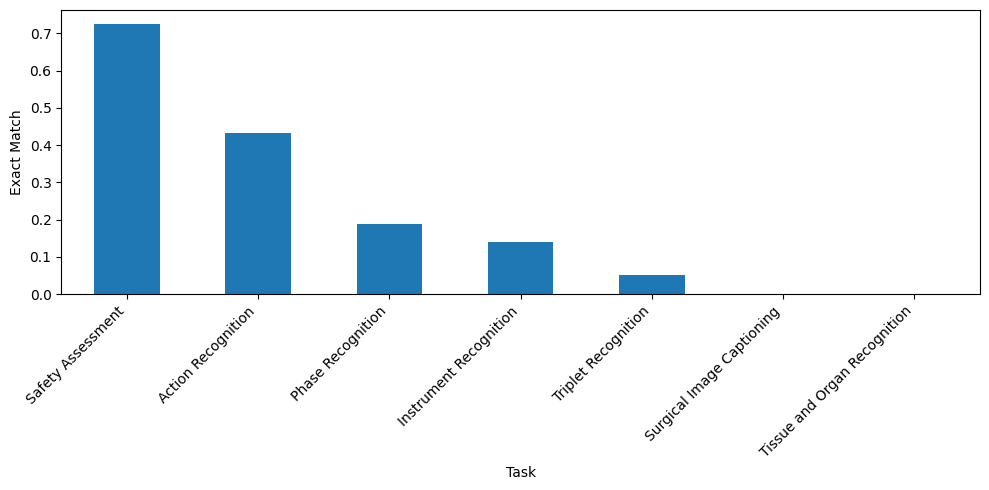

In [ ]:
plt.figure(figsize=(10,5))

task_exact.plot.bar()

plt.ylabel("Exact Match")

plt.xlabel("Task")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()


## Per-task metrics


In [ ]:
import re

# CholecT50 ontology — taken directly from the Triplet Recognition prompt template
# already present in this dataset, so it can't drift from what the model was
# actually prompted with.
INSTRUMENTS = ["irrigator", "bipolar", "grasper", "clipper", "hook", "scissors"]
ACTIONS = ["grasp", "retract", "dissect", "coagulate", "clip", "cut",
           "aspirate", "irrigate", "pack", "null_verb"]
TARGETS = ["blood_vessel", "cystic_plate", "gut", "cystic_pedicle", "peritoneum",
           "null_target", "adhesion", "gallbladder", "liver", "fluid", "omentum",
           "specimen_bag", "cystic_artery", "abdominal_wall_cavity", "cystic_duct"]
PHASES = ["Preparation", "Calot Triangle Dissection", "Clipping Cutting",
          "Gallbladder Dissection", "Gallbladder Packaging",
          "Cleaning Coagulation", "Gallbladder Retraction"]

def _vocab_variants(term):
    t = term.lower()
    return {t, t.replace("_", " "), t.replace(" ", "_")}

def extract_label_set(text, vocab):
    """Extract the SET of vocabulary terms mentioned anywhere in free text.
    Robust to sentence wrappers, JSON wrappers, comma-lists, and repeated/
    looping generations (duplicates collapse naturally into a set)."""
    text = str(text).lower()
    found = set()
    for term in vocab:
        canonical = term.lower().replace(" ", "_")
        for variant in _vocab_variants(term):
            if re.search(r"\b" + re.escape(variant) + r"\b", text):
                found.add(canonical)
                break
    return found

def extract_single_label(text, vocab):
    """First vocabulary term (by list order) found in text, or None if none found."""
    text = str(text).lower()
    for term in vocab:
        for variant in _vocab_variants(term):
            if re.search(r"\b" + re.escape(variant) + r"\b", text):
                return term
    return None

def set_prf1(true_set, pred_set):
    """Per-example precision/recall/F1 over label sets. Both-empty counts as a match."""
    if not true_set and not pred_set:
        return 1.0, 1.0, 1.0
    if not pred_set or not true_set:
        return 0.0, 0.0, 0.0
    tp = len(true_set & pred_set)
    precision = tp / len(pred_set)
    recall = tp / len(true_set)
    f1 = 0.0 if (precision + recall) == 0 else 2 * precision * recall / (precision + recall)
    return precision, recall, f1

def multilabel_set_f1(df, vocab, task_name):
    """Per-row set P/R/F1 for a multi-label recognition task, plus a summary row
    with both the mean-over-examples ('samples' avg) and pooled micro-F1."""
    sub = df[df["task"] == task_name].copy()
    true_sets = sub["answer"].apply(lambda x: extract_label_set(x, vocab))
    pred_sets = sub["prediction"].apply(lambda x: extract_label_set(x, vocab))

    prf = [set_prf1(t, p) for t, p in zip(true_sets, pred_sets)]
    sub["set_precision"] = [x[0] for x in prf]
    sub["set_recall"] = [x[1] for x in prf]
    sub["set_f1"] = [x[2] for x in prf]

    tp = sum(len(t & p) for t, p in zip(true_sets, pred_sets))
    fp = sum(len(p - t) for t, p in zip(true_sets, pred_sets))
    fn = sum(len(t - p) for t, p in zip(true_sets, pred_sets))
    micro_p = tp / (tp + fp) if (tp + fp) else 0.0
    micro_r = tp / (tp + fn) if (tp + fn) else 0.0
    micro_f1 = 0.0 if (micro_p + micro_r) == 0 else 2 * micro_p * micro_r / (micro_p + micro_r)

    summary = {
        "task": task_name,
        "mean_set_precision": sub["set_precision"].mean(),
        "mean_set_recall": sub["set_recall"].mean(),
        "mean_set_f1": sub["set_f1"].mean(),
        "micro_precision": micro_p,
        "micro_recall": micro_r,
        "micro_f1": micro_f1,
        "n": len(sub),
    }
    return sub, summary


In [ ]:
multilabel_tasks = {
    "Action Recognition": ACTIONS,
    "Instrument Recognition": INSTRUMENTS,
    "Tissue and Organ Recognition": TARGETS,
    "Triplet Recognition": INSTRUMENTS + ACTIONS + TARGETS,
}

multilabel_summaries = []
for task_name, vocab in multilabel_tasks.items():
    sub, summary = multilabel_set_f1(results_df, vocab, task_name)
    multilabel_summaries.append(summary)

multilabel_results = pd.DataFrame(multilabel_summaries)
multilabel_results.to_csv(
    "/content/drive/MyDrive/Surgical-VLM/results/MISMATCHEDvisionllm_multilabel_set_f1.csv",
    index=False,
)
multilabel_results


,task,mean_set_precision,mean_set_recall,mean_set_f1,micro_precision,micro_recall,micro_f1,n
0,Action Recognition,0.562711,0.820625,0.618641,0.374159,0.829606,0.515723,800
1,Instrument Recognition,0.464375,0.793750,0.518173,0.364109,0.787381,0.497950,800
2,Tissue and Organ Recognition,0.291938,0.813125,0.419256,0.283248,0.805643,0.419136,800
3,Triplet Recognition,0.520264,0.612226,0.532487,0.494284,0.608201,0.545357,800


**Note on Triplet Recognition:** the set-F1 above extracts the *union* of
instrument, action, and target vocabulary terms mentioned, without enforcing that
predicted terms are correctly bound into the same (instrument, action, target)
triple as the ground truth — the mix of JSON, comma-list, and multi-line sentence
formats in this task makes strict tuple-level parsing unreliable across all rows.
This gives a fair component-recognition score but is a looser standard than exact
triplet matching. The subset of rows using the structured JSON template (`{"answers":
...}`) can be scored more strictly below.

In [ ]:
import json as _json

def parse_json_triplets(text):
    """For rows using the structured '{"answers": "..."}' template, parse out
    (instrument, action, target) tuples. Returns None if the text isn't valid
    JSON in the expected shape."""
    text = str(text).strip()
    try:
        obj = _json.loads(text)
    except Exception:
        return None
    if not isinstance(obj, dict) or "answers" not in obj:
        return None
    raw = obj["answers"]
    if isinstance(raw, str):
        raw = [raw]
    triplets = set()
    for item in raw:
        # strip "A. " style option letters, keep the label words
        words = re.findall(r"[a-zA-Z_]+", str(item).lower())
        # drop single stray letters (the "A", "B", "C" option markers)
        words = [w for w in words if len(w) > 1]
        found = extract_label_set(" ".join(words), INSTRUMENTS + ACTIONS + TARGETS)
        if found:
            triplets.add(frozenset(found))
    return triplets

triplet_df = results_df[results_df["task"] == "Triplet Recognition"].copy()
triplet_df["gt_json_triplets"] = triplet_df["answer"].apply(parse_json_triplets)
triplet_df["pred_json_triplets"] = triplet_df["prediction"].apply(parse_json_triplets)

json_subset = triplet_df[triplet_df["gt_json_triplets"].notna() & triplet_df["pred_json_triplets"].notna()]
print(f"Rows using the structured JSON triplet template: {len(json_subset)} / {len(triplet_df)}")

if len(json_subset) > 0:
    strict_prf = [
        set_prf1(t, p) for t, p in zip(json_subset["gt_json_triplets"], json_subset["pred_json_triplets"])
    ]
    strict_f1 = np.mean([x[2] for x in strict_prf])
    print(f"Strict tuple-level set-F1 on this subset: {strict_f1:.4f}")


Rows using the structured JSON triplet template: 39 / 800
Strict tuple-level set-F1 on this subset: 0.2564


In [ ]:
phase_df = results_df[results_df["task"] == "Phase Recognition"].copy()
phase_df["gt_label"] = phase_df["answer"].apply(lambda x: extract_single_label(x, PHASES))
phase_df["pred_label"] = phase_df["prediction"].apply(lambda x: extract_single_label(x, PHASES))

# rows where a label couldn't be extracted at all (None) are real prediction failures,
# not eval-script noise — keep them as a distinct class rather than silently dropping them
phase_df["gt_label"] = phase_df["gt_label"].fillna("UNPARSEABLE")
phase_df["pred_label"] = phase_df["pred_label"].fillna("UNPARSEABLE")

phase_accuracy = accuracy_score(phase_df["gt_label"], phase_df["pred_label"])
phase_macro_f1 = f1_score(phase_df["gt_label"], phase_df["pred_label"], average="macro", zero_division=0)

print(f"Phase Recognition — Accuracy: {phase_accuracy:.4f}, Macro F1: {phase_macro_f1:.4f}")
print()
print(classification_report(phase_df["gt_label"], phase_df["pred_label"], zero_division=0))

pd.DataFrame([{"task": "Phase Recognition", "accuracy": phase_accuracy, "macro_f1": phase_macro_f1}]).to_csv(
    "/content/drive/MyDrive/Surgical-VLM/results/MISMATCHEDvisionllm_phase_metrics.csv", index=False
)


Phase Recognition — Accuracy: 0.3050, Macro F1: 0.1409

                           precision    recall  f1-score   support

Calot Triangle Dissection       0.37      0.53      0.44       285
     Cleaning Coagulation       0.10      0.12      0.11        34
         Clipping Cutting       0.05      0.06      0.05        52
   Gallbladder Dissection       0.38      0.27      0.31       319
    Gallbladder Packaging       0.00      0.00      0.00        30
   Gallbladder Retraction       0.05      0.06      0.05        17
              Preparation       0.05      0.02      0.02        63

                 accuracy                           0.30       800
                macro avg       0.14      0.15      0.14       800
             weighted avg       0.30      0.30      0.29       800



In [ ]:
safety_df = results_df[results_df["task"] == "Safety Assessment"].copy()

def normalize_yesno(text):
    text = str(text).strip().lower()
    if re.search(r"\byes\b", text):
        return "yes"
    if re.search(r"\bno\b", text):
        return "no"
    return None

def classify_criterion(question):
    q = str(question).lower()
    if "two tubular" in q or "two and only two" in q:
        return "two_tubular_structures_connected"
    if "hepatocystic triangle" in q:
        return "hepatocystic_triangle_cleared"
    if "lower gallbladder detached" in q or "lower third of the cystic plate" in q or "cystic plate" in q:
        return "lower_third_cystic_plate_exposed"
    return "compound_or_unrecognized"

def parse_compound_criteria(text):
    """For the small subset of rows that bundle all 3 criteria into one answer,
    e.g. 'Criterion 1: Yes.\nCriterion 2: No.\nCriterion 3: No.' """
    text = str(text)
    matches = re.findall(r"criterion\s*(\d)\s*[:\-]?\s*(yes|no)", text, flags=re.IGNORECASE)
    return {int(n): v.lower() for n, v in matches}

CRITERION_ORDER = {
    1: "two_tubular_structures_connected",
    2: "hepatocystic_triangle_cleared",
    3: "lower_third_cystic_plate_exposed",
}

rows = []
for _, row in safety_df.iterrows():
    criterion = classify_criterion(row["question"])
    if criterion != "compound_or_unrecognized":
        gt = normalize_yesno(row["answer"])
        pred = normalize_yesno(row["prediction"])
        if gt is not None and pred is not None:
            rows.append({"criterion": criterion, "correct": gt == pred})
    else:
        gt_parsed = parse_compound_criteria(row["answer"])
        pred_parsed = parse_compound_criteria(row["prediction"])
        for n, name in CRITERION_ORDER.items():
            if n in gt_parsed and n in pred_parsed:
                rows.append({"criterion": name, "correct": gt_parsed[n] == pred_parsed[n]})

criterion_df = pd.DataFrame(rows)
per_criterion_accuracy = criterion_df.groupby("criterion")["correct"].mean()
overall_safety_accuracy = criterion_df["correct"].mean()

print(f"Safety Assessment — rows scored: {len(criterion_df)} / {len(safety_df)} "
      f"(unparseable yes/no answers are excluded, not silently counted as wrong)")
print(f"Overall accuracy across all criteria: {overall_safety_accuracy:.4f}")
print()
print(per_criterion_accuracy)

per_criterion_accuracy.to_csv(
    "/content/drive/MyDrive/Surgical-VLM/results/MISMATCHEDvisionllm_safety_per_criterion.csv"
)


Safety Assessment — rows scored: 800 / 800 (unparseable yes/no answers are excluded, not silently counted as wrong)
Overall accuracy across all criteria: 0.7400

criterion
hepatocystic_triangle_cleared       0.960630
lower_third_cystic_plate_exposed    0.554264
two_tubular_structures_connected    0.711806
Name: correct, dtype: float64


## Generation metrics — Captioning only

BLEU, ROUGE, and BERTScore below are restricted to `Surgical Image Captioning`.
Running these on short closed-vocabulary answers

In [ ]:
captioning_df = results_df[results_df["task"] == "Surgical Image Captioning"].copy()
print(f"Captioning rows: {len(captioning_df)}")


Captioning rows: 800


In [ ]:
import nltk
nltk.download('punkt_tab')
smooth = SmoothingFunction().method4

bleu_scores = []

for _, row in tqdm(captioning_df.iterrows(), total=len(captioning_df)):

    reference = [nltk.word_tokenize(row["gt_norm"])]

    prediction = nltk.word_tokenize(row["pred_norm"])

    bleu = sentence_bleu(

        reference,

        prediction,

        smoothing_function=smooth

    )

    bleu_scores.append(bleu)


captioning_df["bleu"] = bleu_scores
print("Mean sentence BLEU (captioning only):", captioning_df["bleu"].mean())

references = [
    [nltk.word_tokenize(x)]
    for x in captioning_df.gt_norm
]

predictions = [
    nltk.word_tokenize(x)
    for x in captioning_df.pred_norm
]

corpus = corpus_bleu(
    references,
    predictions,
    smoothing_function=smooth
)
print("Corpus BLEU (captioning only):", corpus)

captioning_df[["image_full_path", "bleu"]].to_csv(
    "/content/drive/MyDrive/Surgical-VLM/results/MISMATCHEDvisionllm_captioning_bleu.csv",
    index=False,
)


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


  0%|          | 0/800 [00:00<?, ?it/s]

Mean sentence BLEU (captioning only): 0.295992997862896
Corpus BLEU (captioning only): 0.29670387777479773


In [ ]:
scorer = rouge_scorer.RougeScorer(
    ["rouge1", "rouge2", "rougeL"],
    use_stemmer=True
)

rouge1 = []
rouge2 = []
rougel = []

for _, row in tqdm(captioning_df.iterrows(), total=len(captioning_df)):

    scores = scorer.score(
        row["gt_norm"],
        row["pred_norm"]
    )

    rouge1.append(scores["rouge1"].fmeasure)
    rouge2.append(scores["rouge2"].fmeasure)
    rougel.append(scores["rougeL"].fmeasure)

captioning_df["rouge1"] = rouge1
captioning_df["rouge2"] = rouge2
captioning_df["rougeL"] = rougel


rouge_summary = pd.DataFrame({

    "Metric":[
        "ROUGE-1",
        "ROUGE-2",
        "ROUGE-L"
    ],

    "Score":[

        np.mean(rouge1),

        np.mean(rouge2),

        np.mean(rougel)

    ]

})

rouge_summary

rouge_summary.to_csv(
    "/content/drive/MyDrive/Surgical-VLM/results/MISMATCHEDvisionllm_captioning_rouge.csv",
    index=False,
)


  0%|          | 0/800 [00:00<?, ?it/s]

Bert score (captioning only)

In [ ]:
P, R, F1 = bertscore(

    captioning_df["pred_norm"].tolist(),

    captioning_df["gt_norm"].tolist(),

    lang="en",

    verbose=True

)


captioning_df["bert_precision"] = P.numpy()

captioning_df["bert_recall"] = R.numpy()

captioning_df["bert_f1"] = F1.numpy()

bert_summary = pd.DataFrame({

    "Metric":[

        "Precision",

        "Recall",

        "F1"

    ],

    "Value":[

        captioning_df["bert_precision"].mean(),

        captioning_df["bert_recall"].mean(),

        captioning_df["bert_f1"].mean()

    ]

})

bert_summary

bert_summary.to_csv(
    "/content/drive/MyDrive/Surgical-VLM/results/MISMATCHEDvisionllm_captioning_bertscore.csv",
    index=False,
)


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


calculating scores...
computing bert embedding.


  0%|          | 0/15 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/13 [00:00<?, ?it/s]

done in 676.72 seconds, 1.18 sentences/sec
